# 02 · Delivery slots: when do customers order?

**Business question:** on which days and at what times do customers place orders, and how should a delivery-slot grocer like Picnic plan capacity?

**Data note:** timing analysis uses **all orders** (prior + train + test), because test orders have day and hour even without products.

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect("../data/instacart.duckdb", read_only=True)

def q(sql):
    """Run a SQL query and return a pandas DataFrame."""
    return con.sql(sql).df()

## 2.1 Orders by day of week
Count orders for each value of `order_dow` (0–6) and their **share of the total** (%).

Note: Instacart never documented which number is which day. Look at the result and decide which assumption is most reasonable.

In [2]:
q("""
SELECT order_dow, COUNT(*) as n_orders,
        ROUND (COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 1) AS pct_orders
FROM orders
GROUP BY order_dow
ORDER BY order_dow
""")

,order_dow,n_orders,pct_orders
0,0,600905,17.6
1,1,587478,17.2
2,2,467260,13.7
3,3,436972,12.8
4,4,426339,12.5
5,5,453368,13.3
6,6,448761,13.1


Days 0 and 1 (assumed Sunday and Monday, not documented by Instacart) concentrate ~35% of weekly orders. The busiest day has 41% more orders than the quietest one, so capacity must flex across the week.

## 2.2 Orders by hour of day
Count orders for each `order_hour_of_day` (0–23) and their share (%). When is the peak? When is it almost empty?

In [4]:
q("""
SELECT order_hour_of_day, COUNT(*) as n_orders,
        ROUND (COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 1) AS pct_orders
FROM orders
GROUP BY order_hour_of_day
ORDER BY order_hour_of_day
""")

,order_hour_of_day,n_orders,pct_orders
0,00,22758,0.7
1,01,12398,0.4
2,02,7539,0.2
3,03,5474,0.2
4,04,5527,0.2
5,05,9569,0.3
6,06,30529,0.9
7,07,91868,2.7
8,08,178201,5.2
9,09,257812,7.5


Orders are placed mostly during working hours: 71.6% between 9:00 and 17:59, with a flat plateau from 10 to 16 (~8% per hour). Night (0–6) is only 2.7%. This is order time, not delivery time.

## 2.3 Day × hour matrix
Count orders for every combination of day and hour (7 × 24 = 168 rows). Save the result in a variable called `dow_hour`.

In [6]:
dow_hour = q("""
SELECT order_dow,
       CAST(order_hour_of_day AS INTEGER) AS order_hour_of_day,
       COUNT(*) AS n_orders
FROM orders
GROUP BY order_dow, order_hour_of_day
ORDER BY order_dow, order_hour_of_day
""")
dow_hour.head()

,order_dow,order_hour_of_day,n_orders
0,0,0,3936
1,0,1,2398
2,0,2,1409
3,0,3,963
4,0,4,813


### Heatmap
This cell turns `dow_hour` into a heatmap. It expects 3 columns: `order_dow`, `order_hour_of_day`, `n_orders`.

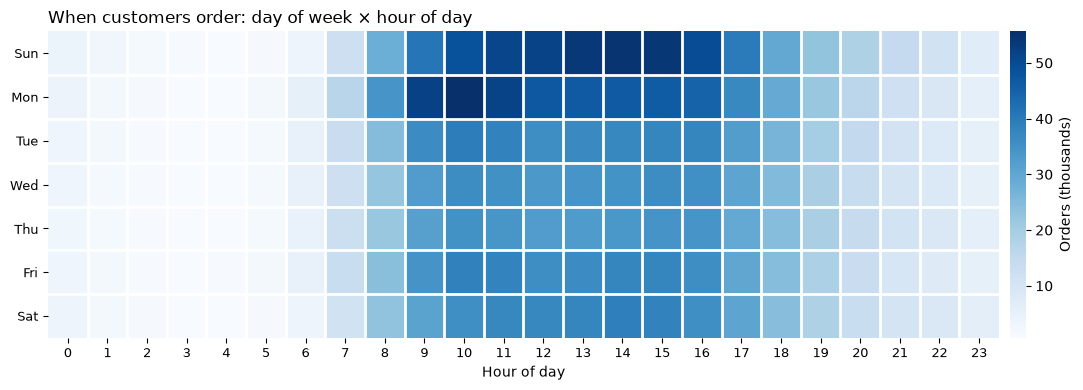

In [7]:
# Day labels: assumption to confirm in 2.1 (0 = Sunday)
DAY_LABELS = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]

matrix = dow_hour.pivot(index="order_dow", columns="order_hour_of_day", values="n_orders").fillna(0)
matrix_k = matrix / 1000  # thousands of orders

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(matrix_k, cmap="Blues", aspect="auto")

# thin white gaps between cells
ax.set_xticks([x - 0.5 for x in range(1, 24)], minor=True)
ax.set_yticks([y - 0.5 for y in range(1, 7)], minor=True)
ax.grid(which="minor", color="white", linewidth=2)
ax.tick_params(which="minor", length=0)

ax.set_xticks(range(24))
ax.set_xticklabels(range(24), fontsize=9)
ax.set_yticks(range(7))
ax.set_yticklabels(DAY_LABELS, fontsize=9)
ax.set_xlabel("Hour of day")
for side in ["top", "right", "left", "bottom"]:
    ax.spines[side].set_visible(False)

cbar = fig.colorbar(im, ax=ax, pad=0.01)
cbar.set_label("Orders (thousands)")
cbar.outline.set_visible(False)

ax.set_title("When customers order: day of week × hour of day", loc="left", fontsize=12)
plt.tight_layout()
plt.savefig("../figures/orders_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 2.4 Orders by time slot
Group the hours into slots with `CASE WHEN` and compute the share of orders per slot:

| Slot | Hours |
|---|---|
| Night | 0–6 |
| Morning | 7–10 |
| Midday | 11–14 |
| Afternoon | 15–17 |
| Evening | 18–23 |

Tip: for the share, divide each slot's count by the total with `SUM(COUNT(*)) OVER ()`.

In [8]:
q("""
SELECT
    CASE
        WHEN CAST(order_hour_of_day AS INTEGER) BETWEEN 0 AND 6   THEN '1. Night (0-6)'
        WHEN CAST(order_hour_of_day AS INTEGER) BETWEEN 7 AND 10  THEN '2. Morning (7-10)'
        WHEN CAST(order_hour_of_day AS INTEGER) BETWEEN 11 AND 14 THEN '3. Midday (11-14)'
        WHEN CAST(order_hour_of_day AS INTEGER) BETWEEN 15 AND 17 THEN '4. Afternoon (15-17)'
        ELSE '5. Evening (18-23)'
    END AS time_slot,
    COUNT(*) AS n_orders,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1) AS pct_orders
FROM orders
GROUP BY time_slot
ORDER BY time_slot
""")

,time_slot,n_orders,pct_orders
0,1. Night (0-6),93794,2.7
1,2. Morning (7-10),816299,23.9
2,3. Midday (11-14),1118610,32.7
3,4. Afternoon (15-17),784987,22.9
4,5. Evening (18-23),607393,17.8


Midday (11–14) has the most orders (32.7%), but slots have different lengths: per hour, midday (8.2%) and afternoon (7.6%) are the busiest, evening is much quieter (3.0%). Order time ≠ delivery time: delivery-slot data would be needed to plan vans.

## 2.5 Peak vs quiet
In the cell matrix, how many times bigger is the busiest day-hour than the median day-hour? (you can use `dow_hour` with pandas, or SQL)

In [11]:
peak = dow_hour["n_orders"].max()
typical = dow_hour["n_orders"].median()
print(peak, typical, round(peak / typical, 1))

55671 18311.5 3.0


In [12]:
dow_hour.sort_values("n_orders", ascending=False).head(5)

,order_dow,order_hour_of_day,n_orders
34,1,10,55671
14,0,14,54552
15,0,15,53954
13,0,13,53849
33,1,9,51908


Peak hour (day 1, 10:00) has 3x the orders of a median hour. Day 0 peaks in the early afternoon (13–15), day 1 in the morning (9–10): consistent with Sunday (at home) and Monday (planning the week at work).

## Findings & recommendation

**1. Demand is concentrated at the start of the week.**
Days 0 and 1 (assumed Sunday and Monday, not documented by Instacart) account for ~35% of weekly orders. The busiest day has 41% more orders than the quietest one (day 4: 12.5% vs day 0: 17.6%).

**2. Customers order during working hours.**
71.6% of orders are placed between 9:00 and 17:59, with a flat plateau from 10:00 to 16:00 (~8% per hour). Normalised by slot length, midday (8.2% per hour) and afternoon (7.6% per hour) are the busiest slots; the evening is much quieter (3.0% per hour) and the night is negligible (2.7% of all orders).

**3. Peaks are 3x a normal hour, and the two peak days behave differently.**
The busiest hour (day 1 at 10:00) has 3x the orders of a median hour. Day 0 peaks in the early afternoon (13–15), day 1 in the morning (9–10), which fits a Sunday at home and a Monday spent planning the week at work.

**Recommendation**
For a fixed-slot grocer like Picnic, demand needs to be smoothed across the week, not only covered at the peak. Small incentives on the quieter days (e.g. lower minimum order or priority slots on Wednesday–Thursday) could move part of the Sunday/Monday demand and use fleet and warehouse capacity more evenly.

**Caveat:** this data shows when customers *place* orders, not when they want them *delivered*. Delivery-slot choices would be needed to plan vans; here the findings mainly inform app traffic, warehouse picking and customer service staffing.